In [6]:
import sys
sys.path.append('/Users/juanrios/Documents/Maestria/master_thesis')
from syntethic_data.syntethic_causal_data import SyntheticCausalSystem
from causal_discovery.causal_discovery import LiNGAMWithFCI, PCWithFCI
from utils.utils import visualize_causal_graph, visualize_comparison
import pandas as pd

In [2]:
# General experiment variables
feats=10
sample=1000
parents_rate=0.6

# Linear system

In [7]:
gen_linear_no_conf=SyntheticCausalSystem(n_features=feats,
                                random_state=42,
                                min_num_connected_edges=2,
                                edge_probability=0.1)
data, adj, conf = gen_linear_no_conf.generate_linear_system(n_samples=sample,
                                                    with_confounders=False,
                                                    noise_std=0.5,
                                                    y_parents_ratio=parents_rate)

data.to_parquet(f"data/linear_no_conf_low_conectivity_{int(feats*parents_rate)}_parents_{feats}_feats.parquet")


In [8]:
lingam_fci = LiNGAMWithFCI(alpha=0.05,indep_test="fisherz")
pci_fci = PCWithFCI(alpha=0.5, indep_test="fisherz")
results_lingam = lingam_fci.get_causal_relationships(data)
results_pc = pci_fci.get_causal_relationships(data)

Running LiNGAM algorithm for causal structure discovery...
LiNGAM discovered 30 edges
Running FCI algorithm for confounder detection...


Depth=0, working on node 10: 100%|██████████| 11/11 [00:00<00:00, 258.84it/s]


X8 --> X9
X8 --> X11
FCI detected 11 potential confounders pairs
 Running PC algorithm for causal structure discovery...


Depth=4, working on node 10: 100%|██████████| 11/11 [00:00<00:00, 617.80it/s]


PC discovered 28 edges
 Running FCI algorithm for confounder detection...


Depth=0, working on node 10: 100%|██████████| 11/11 [00:00<00:00, 330.01it/s]


X9 --> X7
X7 --> X11
FCI detected 14 potential confounders pairs


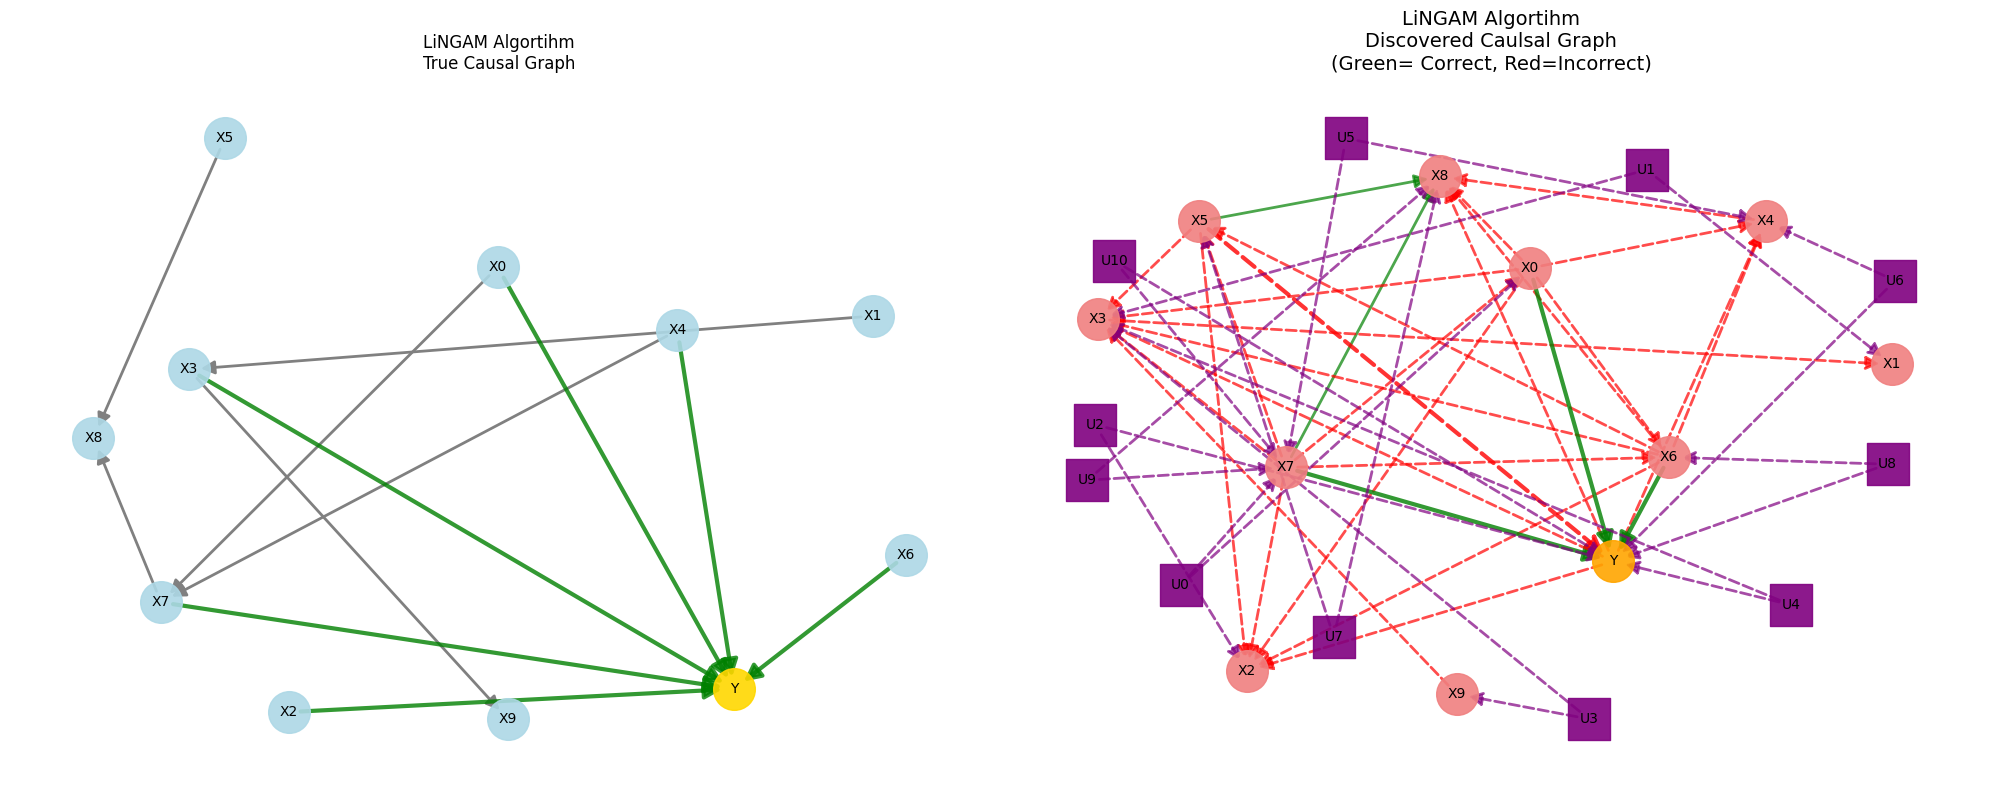

In [ ]:
fig_lingam=visualize_comparison(true_adj=adj,
                     discovered_adj=results_lingam["adjacency_matrix"],
                     features_names=data.columns.tolist(),
                     y_parent_indices=gen_linear_no_conf.y_parent_indices,
                     true_confounders=conf,
                     discovered_confounders=results_lingam["confounders"],
                     title_preix='LiNGAM Algortihm'
                     )

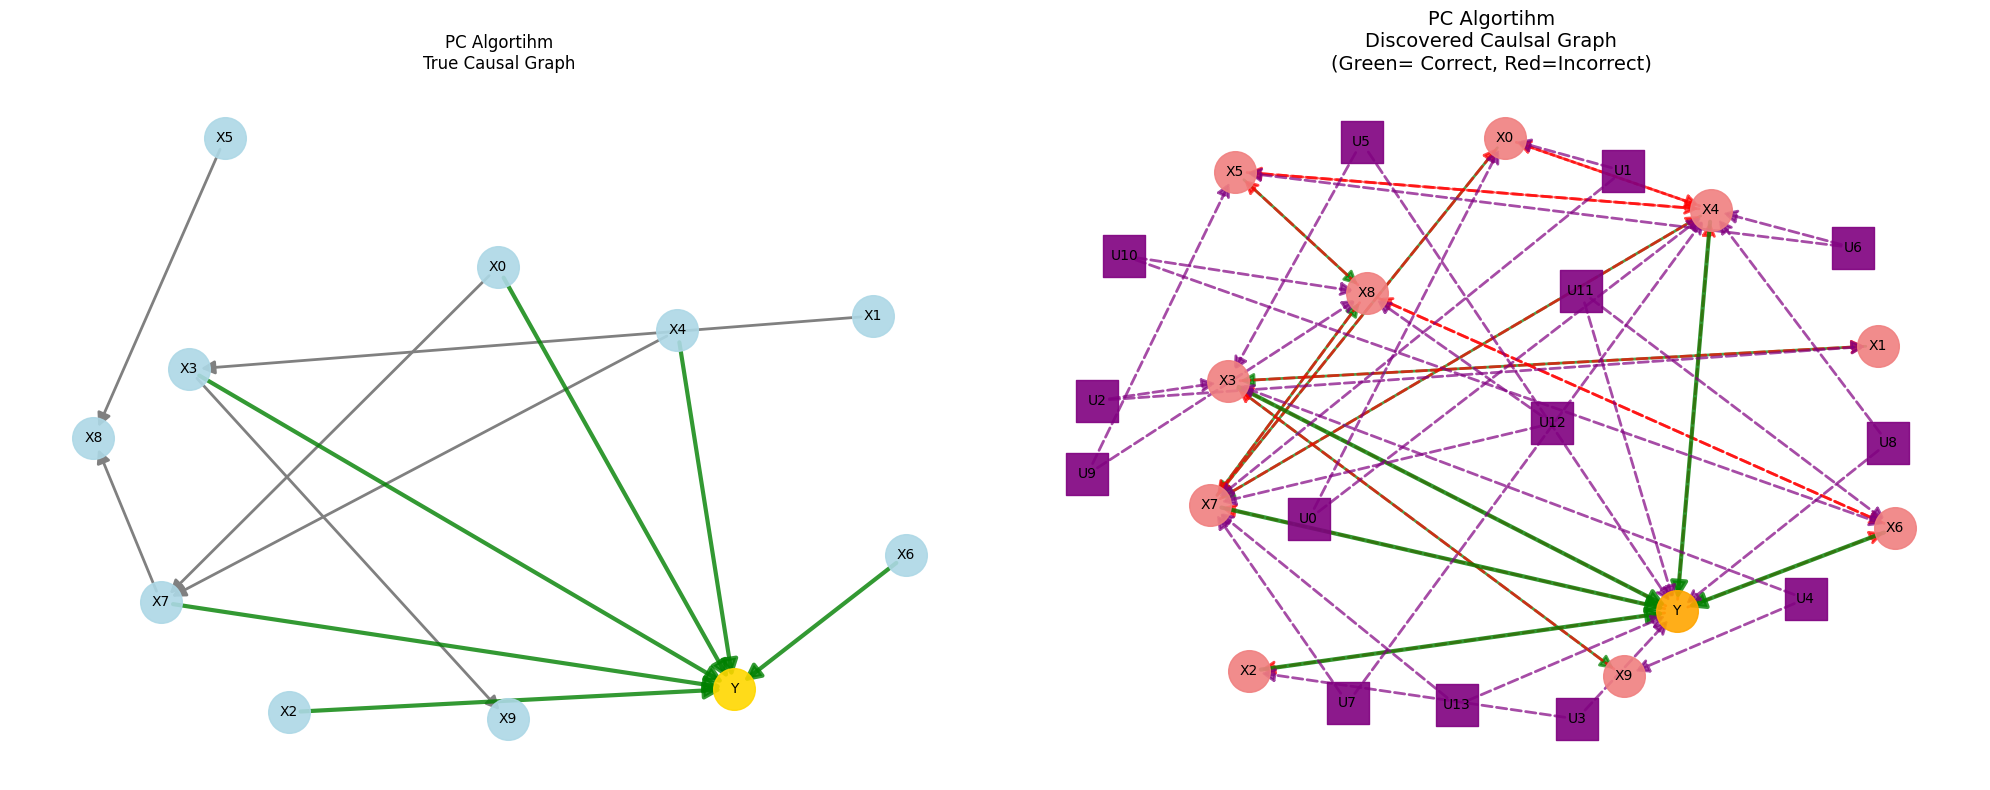

In [9]:
fig_pc=visualize_comparison(true_adj=adj,
                     discovered_adj=results_pc["adjacency_matrix"],
                     features_names=data.columns.tolist(),
                     y_parent_indices=gen_linear_no_conf.y_parent_indices,
                     true_confounders=conf,
                     discovered_confounders=results_pc["confounders"],
                     title_preix='PC Algortihm'
                     )

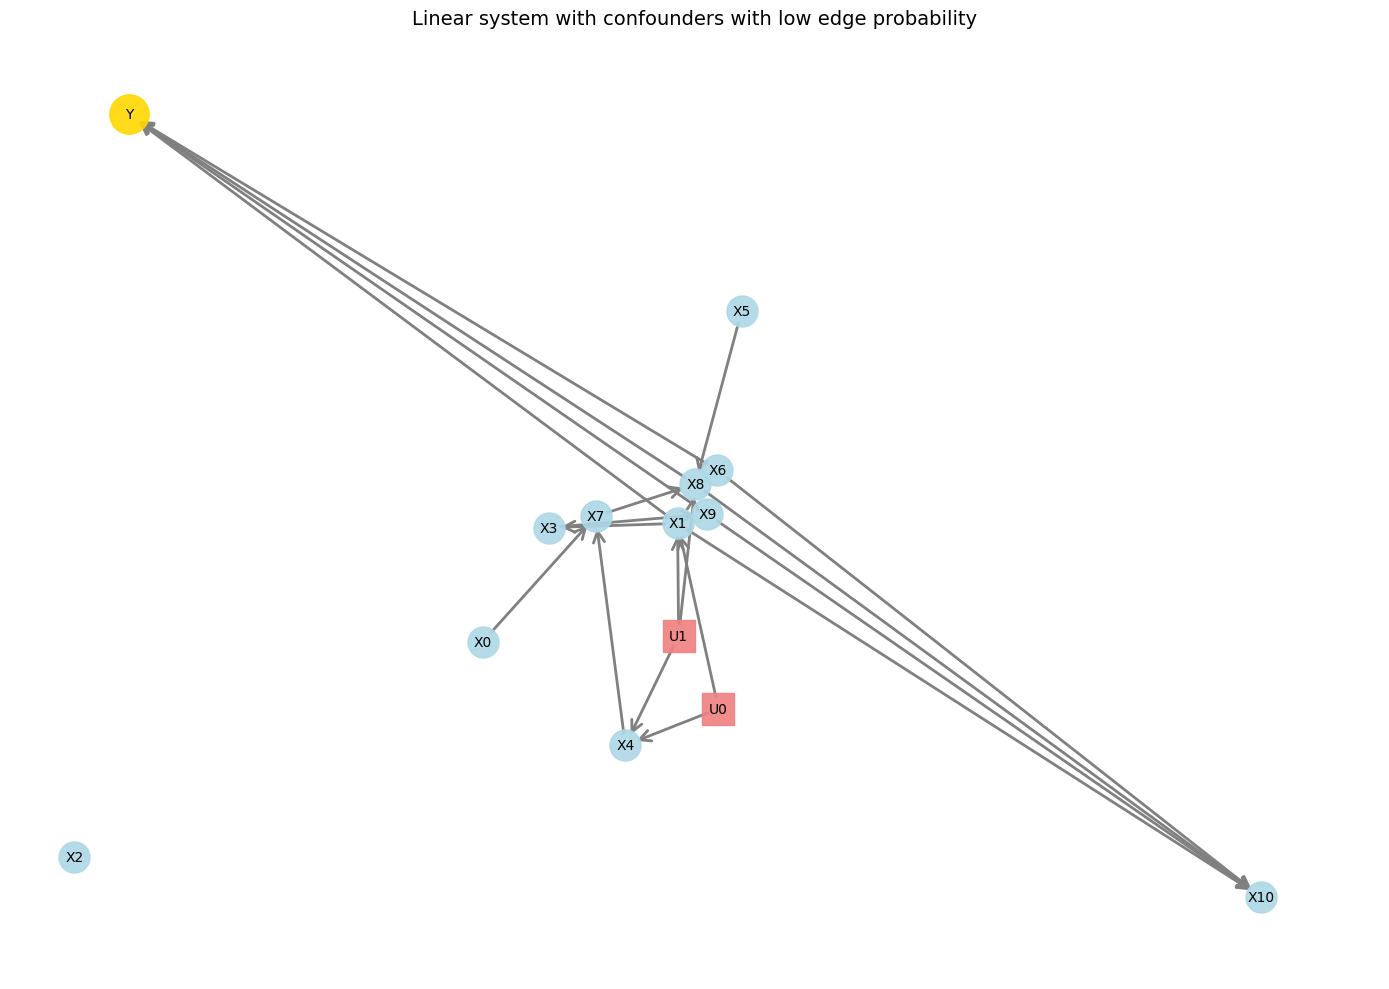

In [16]:

gen_linear_with_conf=SyntheticCausalSystem(n_features=feats,
                                random_state=42,
                                min_num_connected_edges=2,
                                edge_probability=0.1)
data, adj, conf = gen_linear_with_conf.generate_linear_system(n_samples=sample,
                                                    with_confounders=True,
                                                    noise_std=0.5,
                                                    y_parents_ratio=parents_rate)
plt_obj = gen_linear_with_conf.visualize_causal_graph(
    adj,
    conf,
    title='Linear system with confounders with low edge probability',
    y_parent_indices=gen_linear_with_conf.y_parent_indices

)
data.to_parquet(f"data/linear_conf_low_conectivity_{int(feats*parents_rate)}_parents_{feats}_feats.parquet")

In [17]:
conf

[(0, [4, 1]), (1, [1, 8, 4])]

# Non-linear data

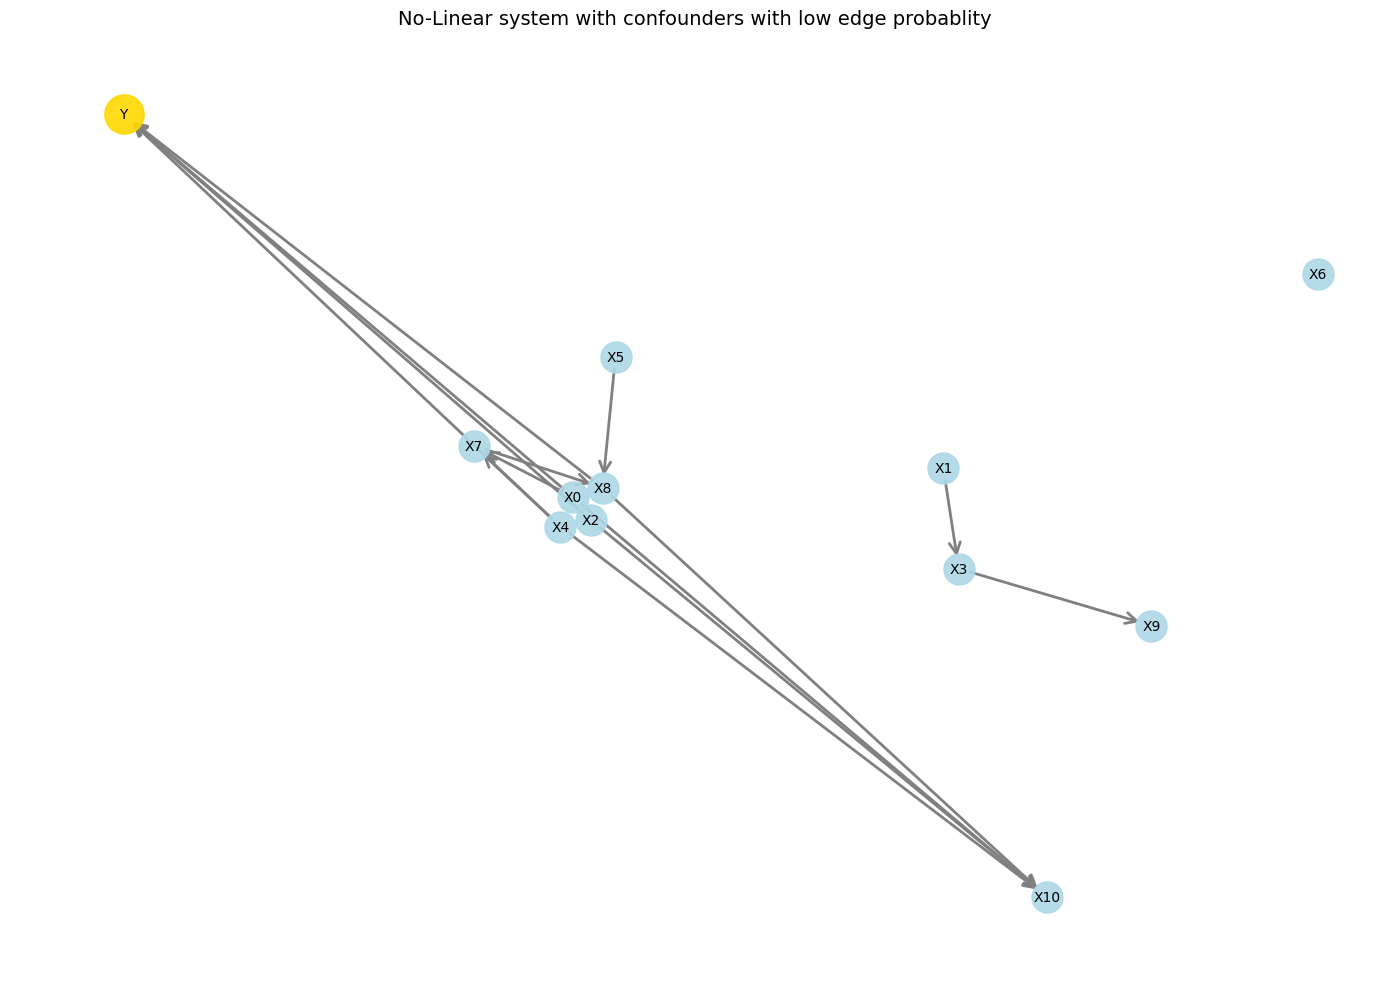

In [6]:
gen_no_linear_no_conf=SyntheticCausalSystem(n_features=feats,
                                random_state=42,
                                min_num_connected_edges=2,
                                edge_probability=0.1)
data, adj, conf = gen_no_linear_no_conf.generate_nonlinear_system(n_samples=sample,
                                                    with_confounders=False,
                                                    noise_std=0.5,
                                                    y_parents_ratio=parents_rate)
plt_obj = gen_no_linear_no_conf.visualize_causal_graph(
    adj,
    conf,
    title='No-Linear system with confounders with low edge probablity',
    y_parent_indices=gen_no_linear_no_conf.y_parent_indices

)
data.to_parquet(f"data/no_linear_no_conf_low_conectivity_{int(feats*parents_rate)}_parents_{feats}_feats.parquet")

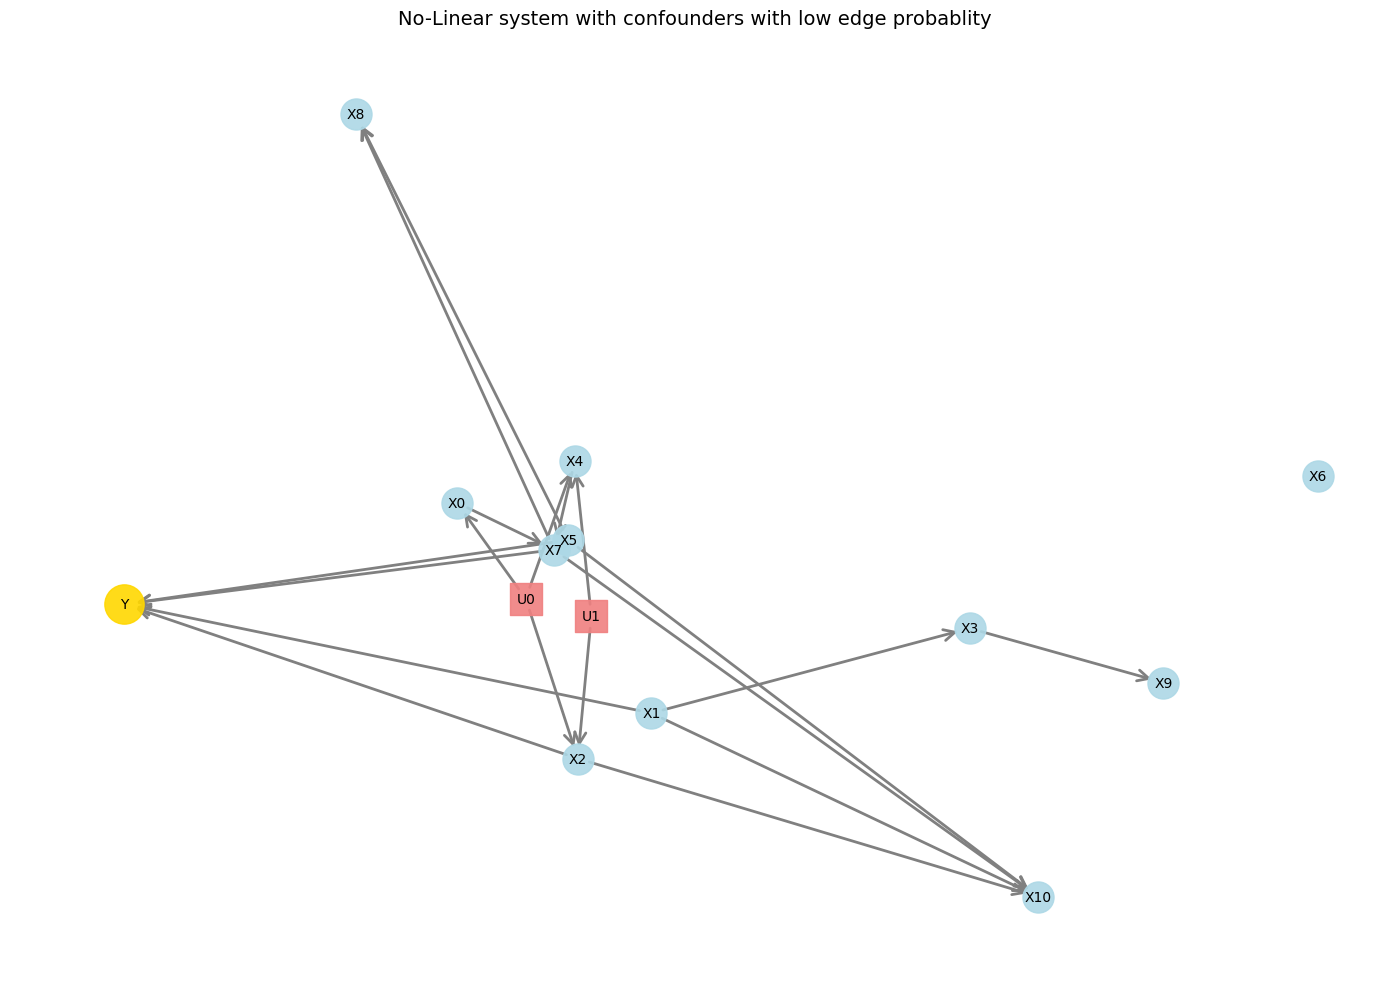

In [7]:
gen_no_linear_conf=SyntheticCausalSystem(n_features=feats,
                                random_state=42,
                                min_num_connected_edges=2,
                                edge_probability=0.1)
data, adj, conf = gen_no_linear_conf.generate_nonlinear_system(n_samples=sample,
                                                    with_confounders=True,
                                                    noise_std=0.5,
                                                    y_parents_ratio=parents_rate)
plt_obj = gen_no_linear_conf.visualize_causal_graph(
    adj,
    conf,
    title='No-Linear system with confounders with low edge probablity',
    y_parent_indices=gen_no_linear_conf.y_parent_indices

)
data.to_parquet(f"data/no_linear_conf_low_conectivity_{int(feats*parents_rate)}_parents_{feats}_feats.parquet")

# Mixed relationships

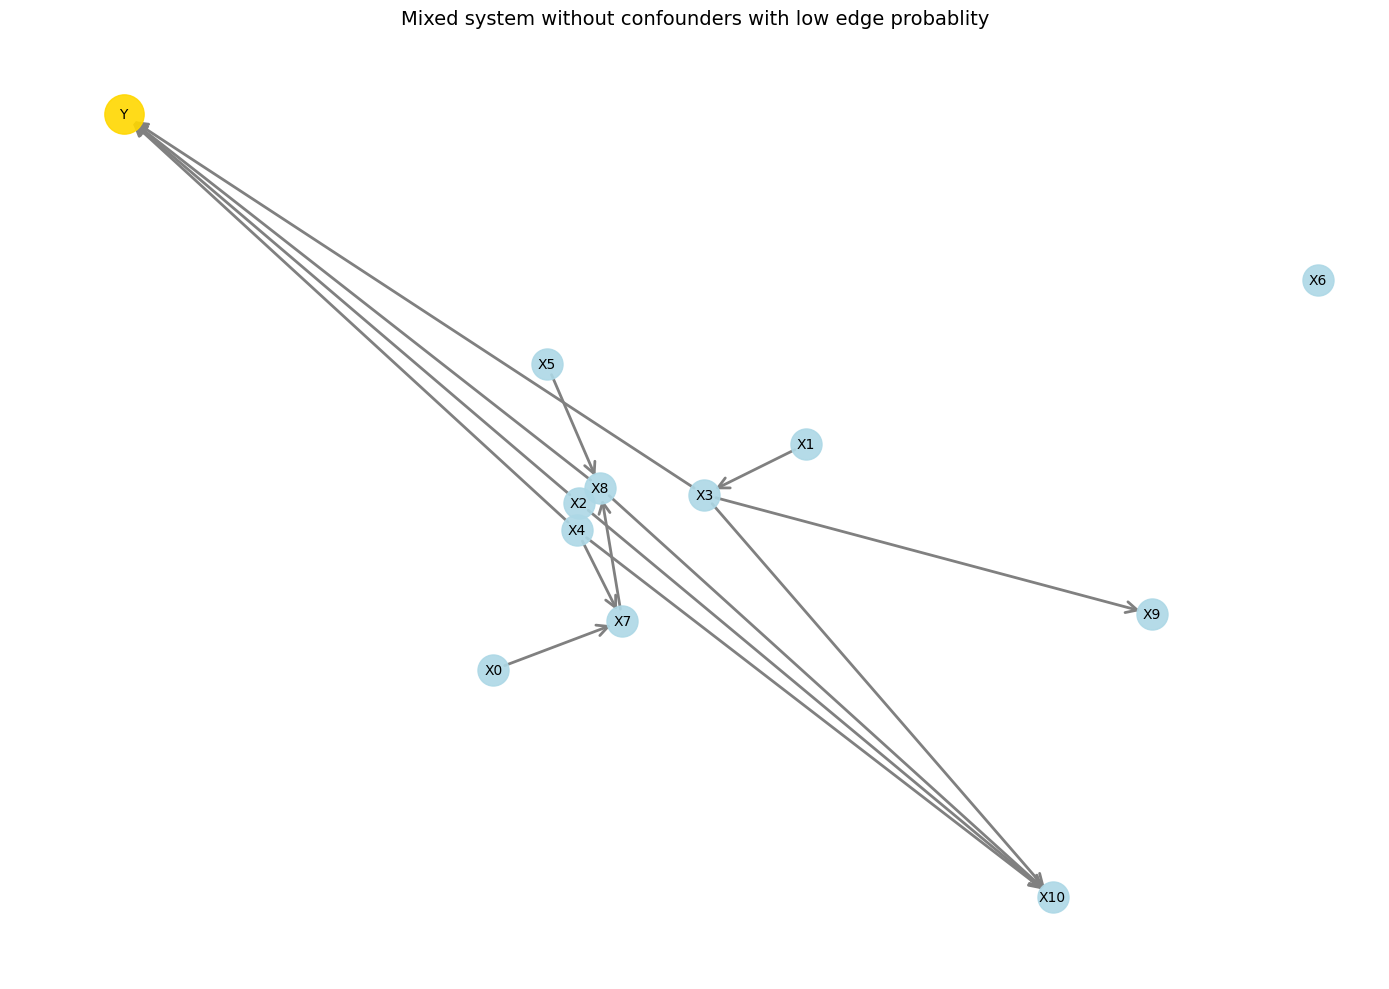

In [8]:
gen_mixed_no_conf=SyntheticCausalSystem(n_features=feats,
                                random_state=42,
                                min_num_connected_edges=2,
                                edge_probability=0.1)
data, adj, conf, edge_types  = gen_mixed_no_conf.generate_mixed_system(n_samples=sample,
                                                    with_confounders=False,
                                                    noise_std=0.5,
                                                    linear_ratio=0.5,
                                                    y_parents_ratio=parents_rate)
plt_obj = gen_mixed_no_conf.visualize_causal_graph(
    adj,
    conf,
    title='Mixed system without confounders with low edge probablity',
    y_parent_indices=gen_mixed_no_conf.y_parent_indices

)
data.to_parquet(f"data/mixed_no_conf_low_conectivity_{int(feats*parents_rate)}_parents_{feats}_feats.parquet")

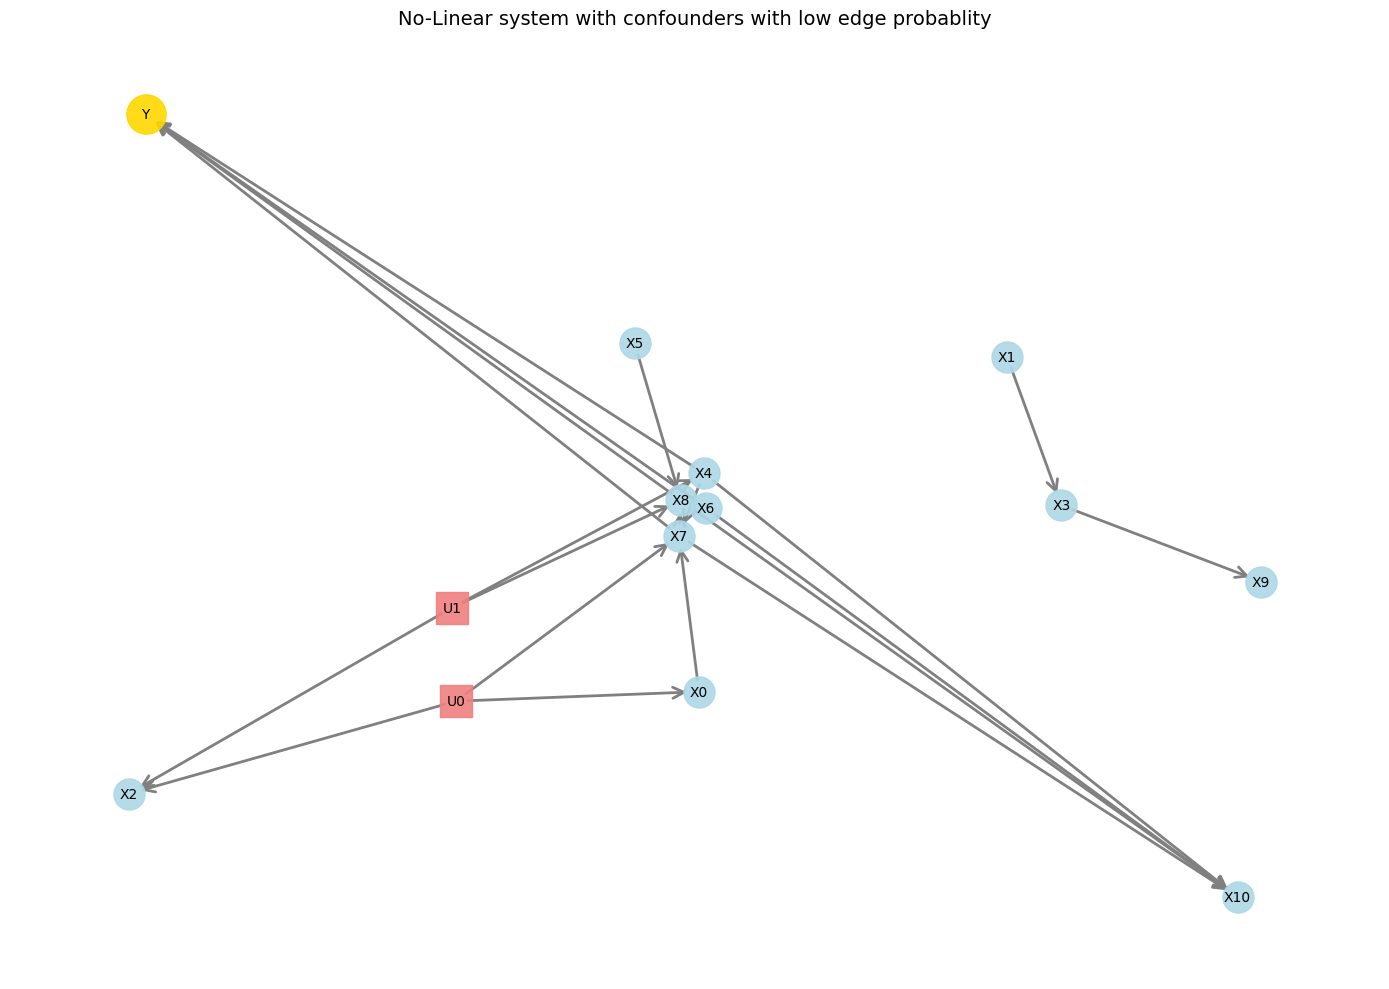

In [9]:
gen_mixed_no_conf=SyntheticCausalSystem(n_features=feats,
                                random_state=42,
                                min_num_connected_edges=2,
                                edge_probability=0.1)
data, adj, conf, edge_types  = gen_mixed_no_conf.generate_mixed_system(n_samples=sample,
                                                    with_confounders=True,
                                                    noise_std=0.5,
                                                    linear_ratio=0.5,
                                                    y_parents_ratio=parents_rate)
plt_obj = gen_mixed_no_conf.visualize_causal_graph(
    adj,
    conf,
    title='No-Linear system with confounders with low edge probablity',
    y_parent_indices=gen_mixed_no_conf.y_parent_indices

)
data.to_parquet(f"data/mixed_conf_low_conectivity_{int(feats*parents_rate)}_parents_{feats}_feats.parquet")